In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

DATA_PATH = Path("walmart_total_weekly.csv")

TEST_WEEKS   = 24 
MIN_TRAIN    = 110 
FOURIER_K    = 2
FOURIER_P    = 52.1775

print("Config OK")


Config OK


In [2]:
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
t = np.arange(len(df))
for k in range(1, FOURIER_K + 1):
    df[f"fourier_sin_{k}"] = np.sin(2 * np.pi * k * t / FOURIER_P)
    df[f"fourier_cos_{k}"] = np.cos(2 * np.pi * k * t / FOURIER_P)

FOURIER_COLS = [c for c in df.columns if c.startswith("fourier_")]

train = df.iloc[:-TEST_WEEKS].copy()
test  = df.iloc[-TEST_WEEKS:].copy()

y_train = train.set_index("Date")["total_weekly_sales"]
y_test  = test.set_index("Date")["total_weekly_sales"]

print(f"Total rows : {len(df)}")
print(f"Train rows : {len(train)}  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Test rows  : {len(test)}   ({test['Date'].min().date()}  → {test['Date'].max().date()})")


Total rows : 143
Train rows : 119  (2010-02-05 → 2012-05-11)
Test rows  : 24   (2012-05-18  → 2012-10-26)


In [5]:
def adf_pvalue(series):
    return adfuller(pd.Series(series).dropna(), autolag="AIC")[1]

def choose_d(series, max_d=2, alpha=0.05):
    series = pd.Series(series).astype(float)
    for d in range(max_d + 1):
        s = series.diff(d).dropna() if d > 0 else series.dropna()
        if len(s) > 10 and adf_pvalue(s) < alpha:
            return d
    return max_d

d = choose_d(y_train)
print(f"ADF-selected d = {d}")
print(f"  p-value (level)       : {adf_pvalue(y_train):.8f}")
if d >= 1:
    print(f"  p-value (1st diff)    : {adf_pvalue(y_train.diff().dropna()):.8f}")

ADF-selected d = 0
  p-value (level)       : 0.00000379


In [6]:
def eval_metrics(y_true, y_pred, model_name="model"):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    smape_val = 100 * np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask])
    return {"model": model_name, "MAE": mae, "RMSE": rmse, "sMAPE (%)": smape_val}

In [ ]:
BASE_EXOG = ["avg_temp", "avg_fuel_price", "avg_cpi", "avg_unemployment"]

FEATURE_SETS = {
    "holiday":      ["holiday_share"] + FOURIER_COLS,
    "holiday_temp": ["holiday_share", "avg_temp"] + FOURIER_COLS,
    "all_exog":     ["holiday_share"] + BASE_EXOG + FOURIER_COLS,
}

ORDER_GRID = [
    (0, d, 1),
    (1, d, 0),
    (1, d, 1),
    (2, d, 1),
    (1, d, 2),
]

full_y = df.set_index("Date")["total_weekly_sales"]
full_X = df.set_index("Date")

print(f"Grid: {len(FEATURE_SETS)} feature sets × {len(ORDER_GRID)} orders = {len(FEATURE_SETS)*len(ORDER_GRID)} specs")
print(f"Rolling CV folds: {len(full_y) - MIN_TRAIN}")


Grid: 3 feature sets × 5 orders = 15 specs
Rolling CV folds: 33


In [9]:
cv_rows = []
total_specs = len(FEATURE_SETS) * len(ORDER_GRID)
done = 0

for fs_name, cols in FEATURE_SETS.items():
    for order in ORDER_GRID:
        done += 1
        actuals, preds = [], []
        failed = False

        for t_end in range(MIN_TRAIN, len(full_y)):
            y_tr = full_y.iloc[:t_end]
            y_te = full_y.iloc[t_end]
            X_tr = full_X.iloc[:t_end][cols]
            X_te = full_X.iloc[t_end:t_end+1][cols]

            try:
                res = SARIMAX(
                    y_tr,
                    exog=X_tr,
                    order=order,
                    seasonal_order=(0, 0, 0, 0),
                    trend="c",
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=80)
                pred = res.get_forecast(steps=1, exog=X_te).predicted_mean.iloc[0]
                preds.append(pred)
                actuals.append(y_te)
            except Exception:
                failed = True
                break

        if not failed and len(preds) > 0:
            m = eval_metrics(actuals, preds, f"{fs_name}|ARIMA{order}")
            m["feature_set"] = fs_name
            m["order"] = str(order)
            cv_rows.append(m)

        last_rmse = f"{cv_rows[-1]['RMSE']:,.0f}" if not failed else "FAILED"
        print(f"  [{done}/{total_specs}] {fs_name} | {order} — {last_rmse}")

cv_results = pd.DataFrame(cv_rows).sort_values("RMSE").reset_index(drop=True)
print("\n─── Rolling CV Results (ranked by RMSE) ───")
display(cv_results[["model","MAE","RMSE","sMAPE (%)"]].round(1))


  [1/15] holiday | (0, 0, 1) — 10,478,768
  [2/15] holiday | (1, 0, 0) — 10,493,435
  [3/15] holiday | (1, 0, 1) — 10,493,799
  [4/15] holiday | (2, 0, 1) — 10,574,212
  [5/15] holiday | (1, 0, 2) — 10,567,712
  [6/15] holiday_temp | (0, 0, 1) — 2,914,007
  [7/15] holiday_temp | (1, 0, 0) — 2,924,211
  [8/15] holiday_temp | (1, 0, 1) — 2,952,640
  [9/15] holiday_temp | (2, 0, 1) — 2,993,025
  [10/15] holiday_temp | (1, 0, 2) — 2,873,214
  [11/15] all_exog | (0, 0, 1) — 2,541,069
  [12/15] all_exog | (1, 0, 0) — 2,520,546
  [13/15] all_exog | (1, 0, 1) — 2,530,241
  [14/15] all_exog | (2, 0, 1) — 2,941,604
  [15/15] all_exog | (1, 0, 2) — 2,594,617

─── Rolling CV Results (ranked by RMSE) ───


,model,MAE,RMSE,sMAPE (%)
0,"all_exog|ARIMA(1, 0, 0)",1717071.6,2520546.4,3.7
1,"all_exog|ARIMA(1, 0, 1)",1725841.2,2530241.4,3.7
2,"all_exog|ARIMA(0, 0, 1)",1738460.2,2541068.7,3.7
3,"all_exog|ARIMA(1, 0, 2)",1836557.3,2594616.8,3.9
4,"holiday_temp|ARIMA(1, 0, 2)",2291162.0,2873213.6,4.9
5,"holiday_temp|ARIMA(0, 0, 1)",2412587.6,2914007.2,5.2
6,"holiday_temp|ARIMA(1, 0, 0)",2425528.1,2924211.1,5.2
7,"all_exog|ARIMA(2, 0, 1)",2156971.1,2941603.8,4.7
8,"holiday_temp|ARIMA(1, 0, 1)",2424066.9,2952639.6,5.2
9,"holiday_temp|ARIMA(2, 0, 1)",2460521.5,2993024.7,5.3


══════════════════════════════════════════════════
  Best spec (rolling CV)
  Feature set : all_exog
  Features    : ['holiday_share', 'avg_temp', 'avg_fuel_price', 'avg_cpi', 'avg_unemployment', 'fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2']
  ARIMA order : (1, 0, 0)
  Rolling CV RMSE  :       2,520,546
  Rolling CV MAE   :       1,717,072
  Rolling CV sMAPE :           3.68%
══════════════════════════════════════════════════


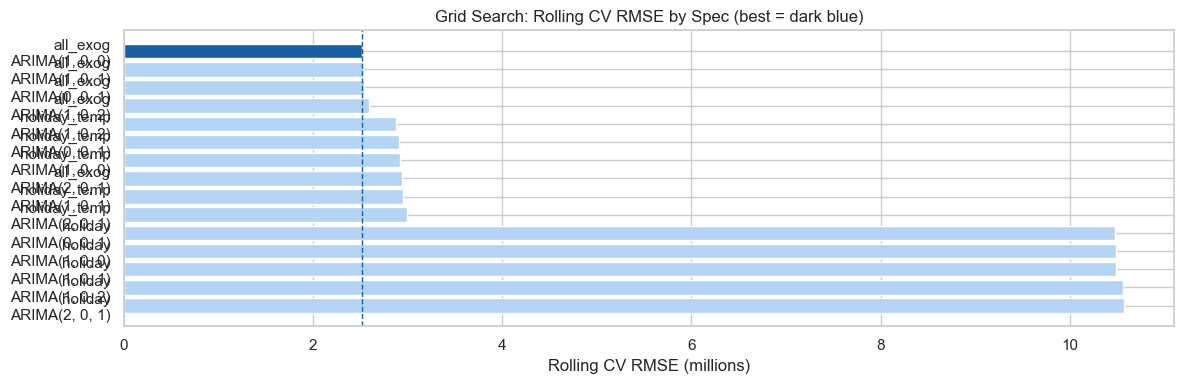

In [10]:
best = cv_results.iloc[0]
best_feature_set = best["feature_set"]
best_features    = FEATURE_SETS[best_feature_set]
best_order       = eval(best["order"])

print("═" * 50)
print(f"  Best spec (rolling CV)")
print(f"  Feature set : {best_feature_set}")
print(f"  Features    : {best_features}")
print(f"  ARIMA order : {best_order}")
print(f"  Rolling CV RMSE  : {best['RMSE']:>15,.0f}")
print(f"  Rolling CV MAE   : {best['MAE']:>15,.0f}")
print(f"  Rolling CV sMAPE : {best['sMAPE (%)']:>14.2f}%")
print("═" * 50)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["#185FA5" if i == 0 else "#B5D4F4" for i in range(len(cv_results))]
labels = [r["model"].replace("|", "\n") for _, r in cv_results.iterrows()]
ax.barh(labels, cv_results["RMSE"] / 1e6, color=colors)
ax.set_xlabel("Rolling CV RMSE (millions)")
ax.set_title("Grid Search: Rolling CV RMSE by Spec (best = dark blue)")
ax.invert_yaxis()
ax.axvline(best["RMSE"] / 1e6, color="#185FA5", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


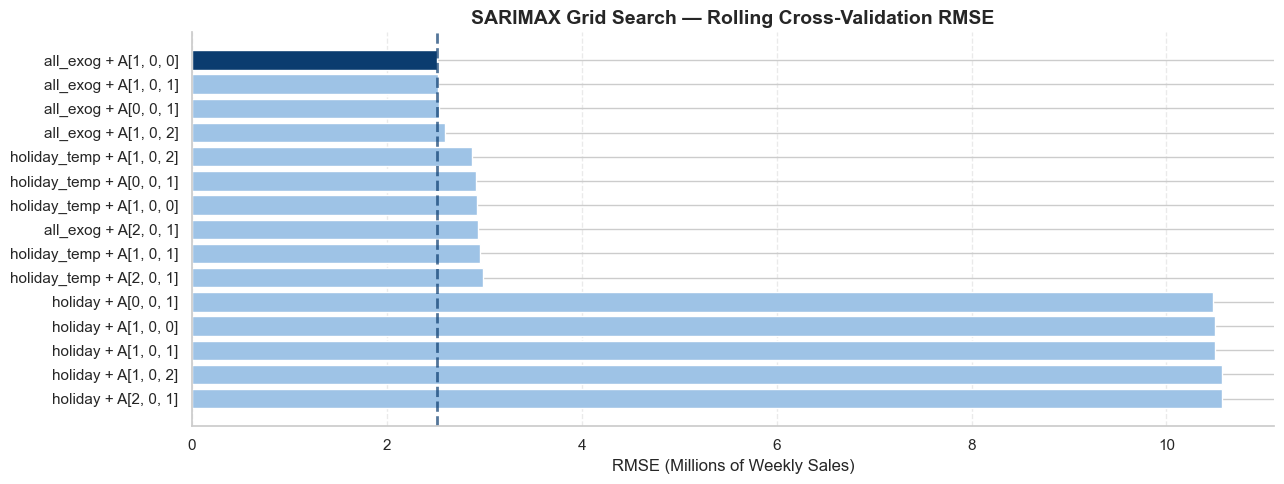

In [24]:
plot_df = cv_results.sort_values("RMSE").reset_index(drop=True)

best = plot_df.iloc[0]
def clean_label(x):
    x = x.replace("|", " + ")
    x = x.replace("ARIMA", "A")
    x = x.replace("(", "[")
    x = x.replace(")", "]")
    return x

labels = [clean_label(m) for m in plot_df["model"]]

colors = ["#0B3C6F"] + ["#9EC3E6"]*(len(plot_df)-1)

fig, ax = plt.subplots(figsize=(13,5))

bars = ax.barh(
    labels,
    plot_df["RMSE"]/1e6,
    color=colors
)

ax.invert_yaxis()

ax.axvline(
    best["RMSE"]/1e6,
    linestyle="--",
    linewidth=2,
    color="#0B3C6F",
    alpha=0.7
)

ax.set_title(
    "SARIMAX Grid Search — Rolling Cross-Validation RMSE",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("RMSE (Millions of Weekly Sales)")

ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
X_train_best = train.set_index("Date")[best_features]
X_test_best  = test.set_index("Date")[best_features]

final_model = SARIMAX(
    y_train,
    exog=X_train_best,
    order=best_order,
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=120)

print(final_model.summary())


                               SARIMAX Results                                
Dep. Variable:     total_weekly_sales   No. Observations:                  119
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1991.066
Date:                Sat, 14 Mar 2026   AIC                           4006.132
Time:                        07:36:14   BIC                           4039.380
Sample:                    02-05-2010   HQIC                          4019.631
                         - 05-11-2012                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept        -3.131e+04   2.99e+04     -1.049      0.294   -8.98e+04    2.72e+04
holiday_share     3.113e+06   6.09e+05      5.113      0.000    1.92e+06    4.31e+06
avg_temp          3.498e+05 

In [12]:
sarimax_pred = final_model.get_forecast(
    steps=len(y_test), exog=X_test_best
).predicted_mean

sarimax_ci = final_model.get_forecast(
    steps=len(y_test), exog=X_test_best
).conf_int(alpha=0.05)

sarimax_holdout = eval_metrics(y_test, sarimax_pred, "SARIMAX (best spec)")
print("Holdout test metrics:")
display(pd.DataFrame([sarimax_holdout]).round(1))

Holdout test metrics:


,model,MAE,RMSE,sMAPE (%)
0,SARIMAX (best spec),2164634.3,2787751.3,4.7


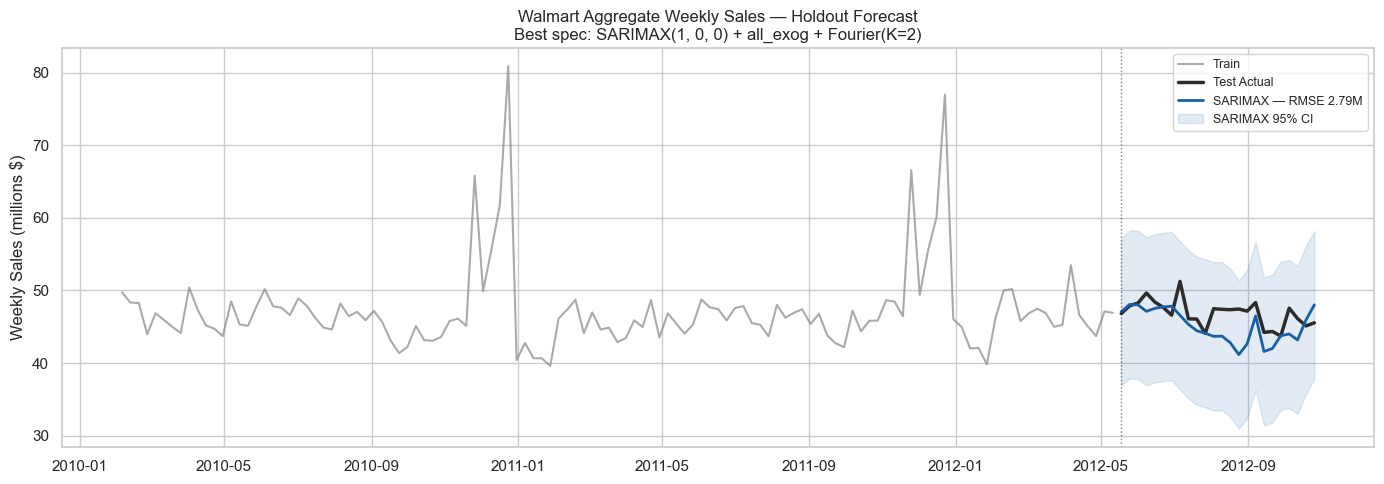

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_train.index, y_train / 1e6,
        label="Train", color="#888780", linewidth=1.5, alpha=0.7)
ax.plot(y_test.index, y_test / 1e6,
        label="Test Actual", color="#2C2C2A", linewidth=2.5)
ax.plot(sarimax_pred.index, sarimax_pred / 1e6,
        label=f"SARIMAX — RMSE {sarimax_holdout['RMSE']/1e6:.2f}M",
        color="#185FA5", linewidth=2, linestyle="-")

# 95% CI for SARIMAX
ax.fill_between(
    sarimax_ci.index,
    sarimax_ci.iloc[:, 0] / 1e6,
    sarimax_ci.iloc[:, 1] / 1e6,
    color="#185FA5", alpha=0.12, label="SARIMAX 95% CI"
)

ax.axvline(y_test.index[0], color="black", linestyle=":", linewidth=1, alpha=0.5)
ax.set_title(
    f"Walmart Aggregate Weekly Sales — Holdout Forecast\n"
    f"Best spec: SARIMAX{best_order} + {best_feature_set} + Fourier(K={FOURIER_K})",
    fontsize=12
)
ax.set_ylabel("Weekly Sales (millions $)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


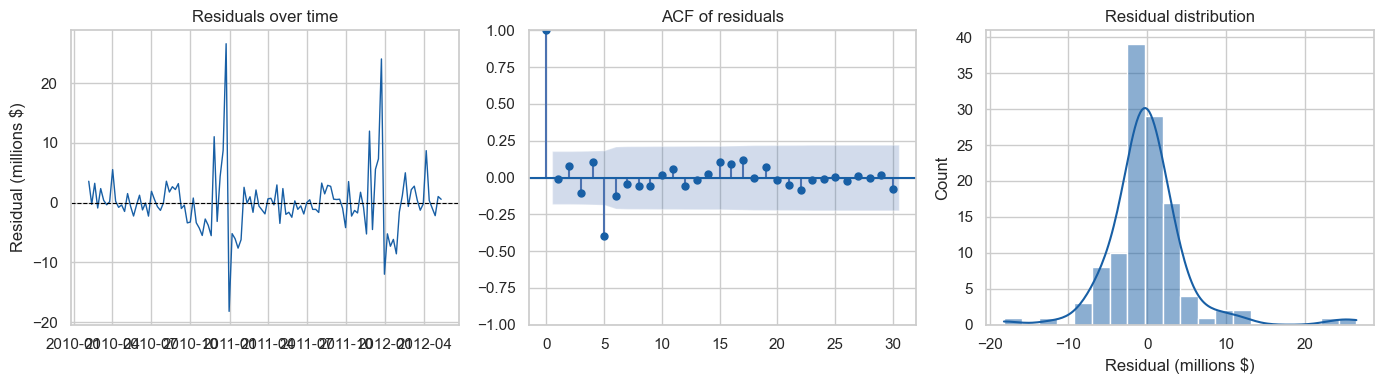


Ljung-Box test (H0: residuals are white noise):


,lb_stat,lb_pvalue
8,25.966618,0.001064
12,27.404927,0.006754
20,32.872086,0.034847


  p > 0.05 → fail to reject H0 → residuals look like white noise ✓


In [14]:
resid = final_model.resid.dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(resid.index, resid / 1e6, color="#185FA5", linewidth=1)
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Residuals over time")
axes[0].set_ylabel("Residual (millions $)")

plot_acf(resid, lags=30, ax=axes[1], color="#185FA5")
axes[1].set_title("ACF of residuals")

sns.histplot(resid / 1e6, bins=20, kde=True, ax=axes[2], color="#185FA5")
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("Residual (millions $)")

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=[8, 12, 20], return_df=True)
print("\nLjung-Box test (H0: residuals are white noise):")
display(lb)
print("  p > 0.05 → fail to reject H0 → residuals look like white noise ✓")


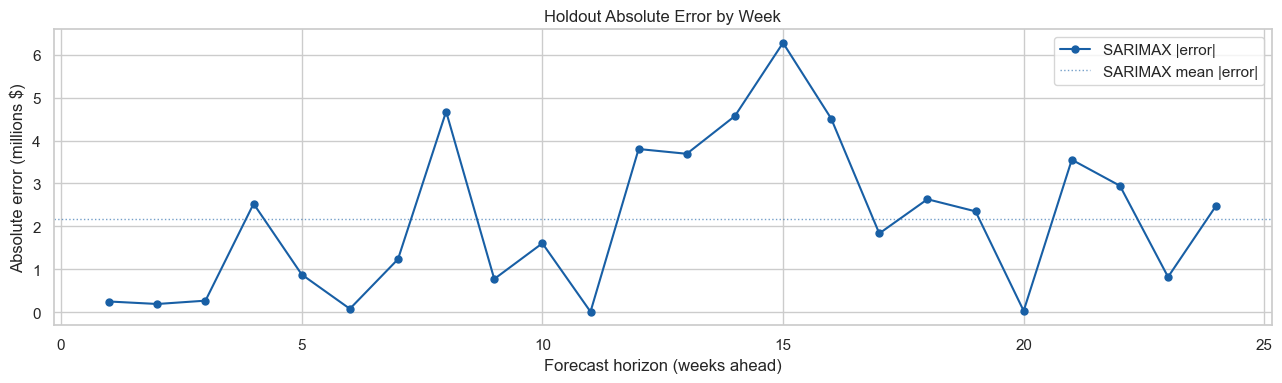


Forecast detail:


,actual,sarimax,sarimax_err
2012-05-18,46823939.0,47069195.0,0.0
2012-05-25,47892463.0,48080031.0,0.0
2012-06-01,48281650.0,48016628.0,0.0
2012-06-08,49651172.0,47125790.0,3.0
2012-06-15,48412111.0,47537663.0,1.0
2012-06-22,47668285.0,47743386.0,0.0
2012-06-29,46597112.0,47829477.0,1.0
2012-07-06,51253022.0,46576960.0,5.0
2012-07-13,46099732.0,45329393.0,1.0
2012-07-20,46059543.0,44456078.0,2.0


In [19]:
forecast_df = pd.DataFrame({
    "actual":    y_test,
    "sarimax":   sarimax_pred,
})
forecast_df["sarimax_err"] = (forecast_df["sarimax"] - forecast_df["actual"]).abs() / 1e6

forecast_df["week"]        = range(1, len(forecast_df) + 1)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(forecast_df["week"], forecast_df["sarimax_err"],
        marker="o", markersize=5, label="SARIMAX |error|", color="#185FA5")

ax.axhline(forecast_df["sarimax_err"].mean(), color="#185FA5",
           linestyle=":", linewidth=1, alpha=0.6, label="SARIMAX mean |error|")
ax.set_xlabel("Forecast horizon (weeks ahead)")
ax.set_ylabel("Absolute error (millions $)")
ax.set_title("Holdout Absolute Error by Week")
ax.legend()
plt.tight_layout()
plt.show()

print("\nForecast detail:")
display(forecast_df[["actual", "sarimax", "sarimax_err"]].round(0))


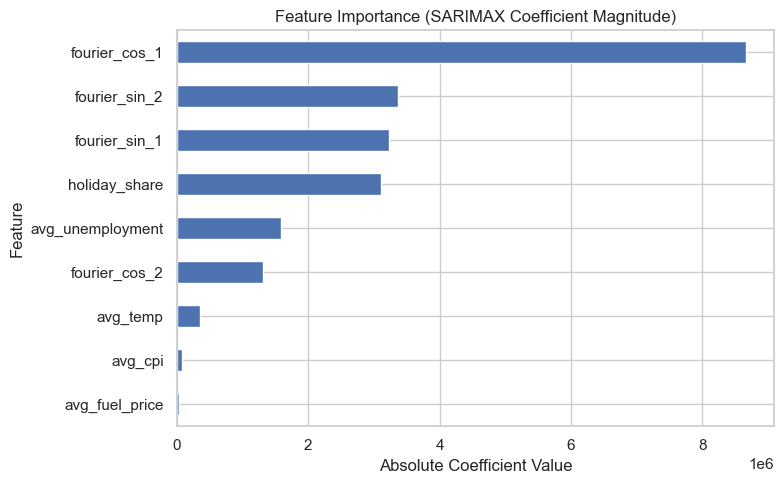

In [23]:
# Extract coefficients from the fitted SARIMAX model
params = final_model.params

exog_vars = [col for col in X_train_best.columns if col in params.index]

importance = params[exog_vars].abs().sort_values()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
importance.plot(kind='barh')

plt.title("Feature Importance (SARIMAX Coefficient Magnitude)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

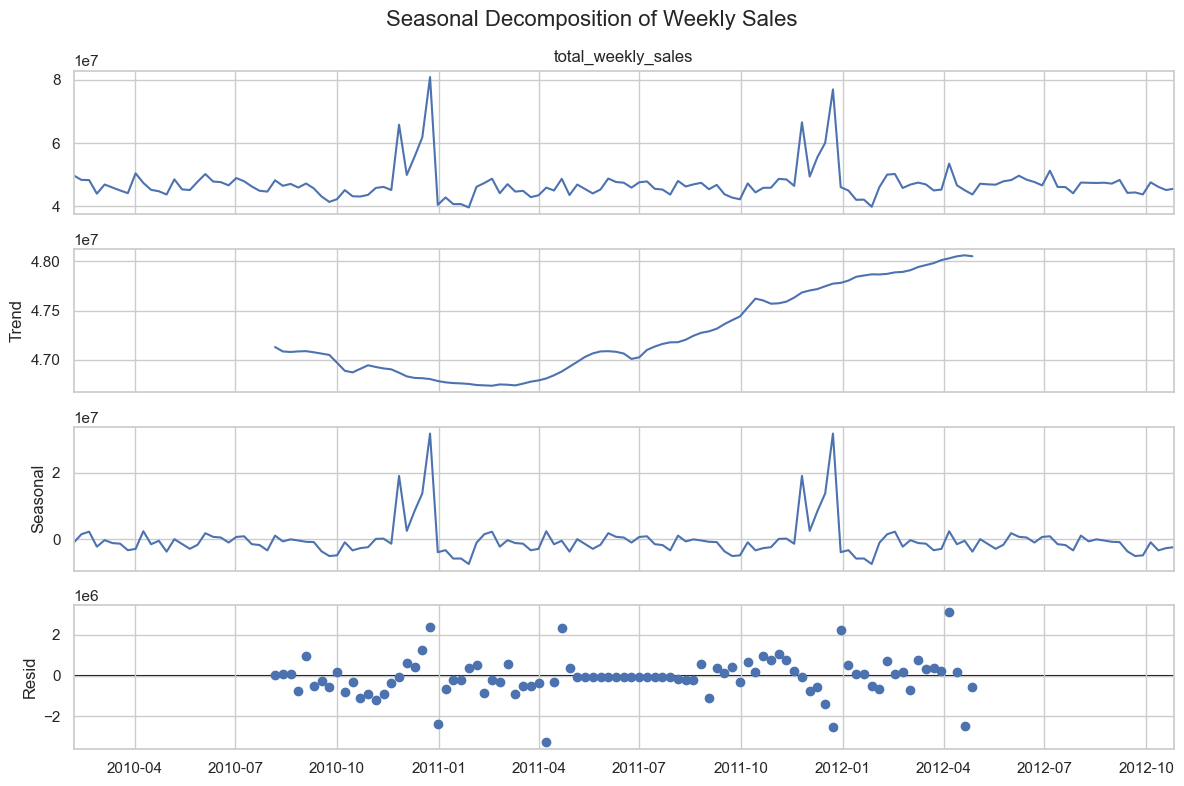

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

series = df.set_index("Date")["total_weekly_sales"]
result = seasonal_decompose(series, model="additive", period=52)

fig = result.plot()
fig.set_size_inches(12,8)

plt.suptitle("Seasonal Decomposition of Weekly Sales", fontsize=16)
plt.tight_layout()
plt.show()

Three stores SARIMAX

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

df = pd.read_csv("walmart_three_stores.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Store","Date"])

stores = df["Store"].unique()
print("Stores:", stores)

Stores: [20 33 34]


In [27]:
def add_fourier_terms(df, period=52.1775, K=2):

    df = df.copy()
    t = np.arange(len(df))

    for k in range(1, K+1):
        df[f"fourier_sin_{k}"] = np.sin(2*np.pi*k*t/period)
        df[f"fourier_cos_{k}"] = np.cos(2*np.pi*k*t/period)

    return df

In [28]:
def run_sarimax_store(store_df):

    store_df = add_fourier_terms(store_df)

    exog_cols = [
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment",
        "holiday",
        "fourier_sin_1",
        "fourier_cos_1",
        "fourier_sin_2",
        "fourier_cos_2"
    ]

    split = int(len(store_df)*0.8)

    train = store_df.iloc[:split]
    test = store_df.iloc[split:]

    model = SARIMAX(
        train["Weekly_Sales"],
        exog=train[exog_cols],
        order=(1,0,0),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    forecast = fit.get_forecast(
        steps=len(test),
        exog=test[exog_cols]
    )

    preds = forecast.predicted_mean

    mae = np.mean(np.abs(preds - test["Weekly_Sales"]))
    rmse = np.sqrt(np.mean((preds - test["Weekly_Sales"])**2))

    smape = np.mean(
        2*np.abs(preds-test["Weekly_Sales"])/
        (np.abs(preds)+np.abs(test["Weekly_Sales"]))
    )*100

    return train,test,preds,mae,rmse,smape

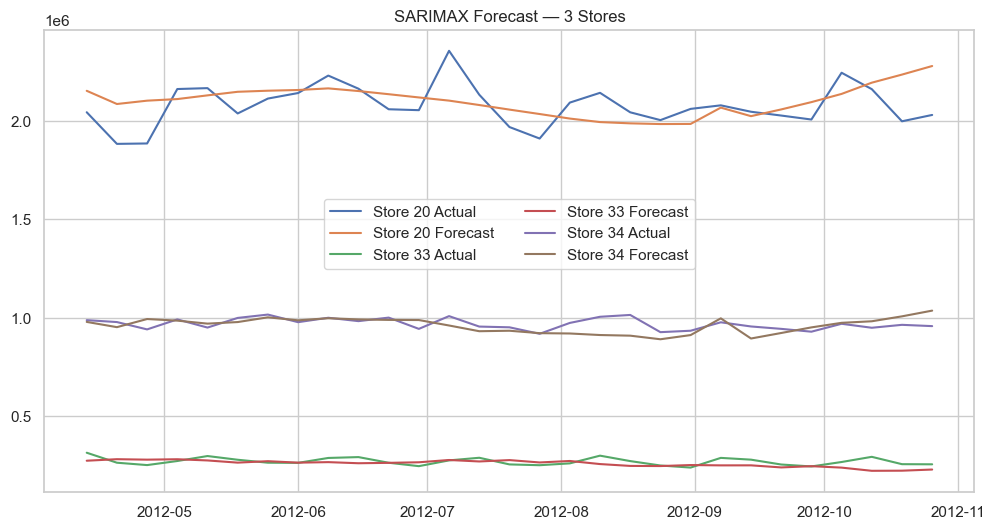

,Store,MAE,RMSE,sMAPE
0,20,92596.454105,117765.202779,4.432396
1,33,20987.026867,25869.357165,7.976541
2,34,31468.923744,41019.479338,3.274051


In [37]:
results = []

plt.figure(figsize=(12,6))

for store in stores:

    store_df = df[df["Store"]==store].reset_index(drop=True)

    train,test,preds,mae,rmse,smape = run_sarimax_store(store_df)

    results.append({
        "Store":store,
        "MAE":mae,
        "RMSE":rmse,
        "sMAPE":smape
    })

    plt.plot(test["Date"],test["Weekly_Sales"],label=f"Store {store} Actual")
    plt.plot(test["Date"],preds,label=f"Store {store} Forecast")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.65),
    ncol=2,
    frameon=True
)
plt.title("SARIMAX Forecast — 3 Stores")
plt.show()

results_df = pd.DataFrame(results)
results_df

In [30]:
results_df.style.format({
    "MAE":"{:,.0f}",
    "RMSE":"{:,.0f}",
    "sMAPE":"{:.2f}%"
})

,Store,MAE,RMSE,sMAPE
0,20,"92,596","117,765",4.43%
1,33,"20,987","25,869",7.98%
2,34,"31,469","41,019",3.27%


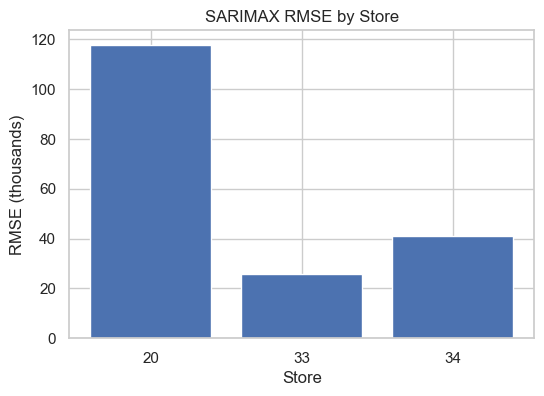

In [31]:
plt.figure(figsize=(6,4))

plt.bar(results_df["Store"].astype(str), results_df["RMSE"]/1e3)

plt.title("SARIMAX RMSE by Store")
plt.ylabel("RMSE (thousands)")
plt.xlabel("Store")

plt.show()

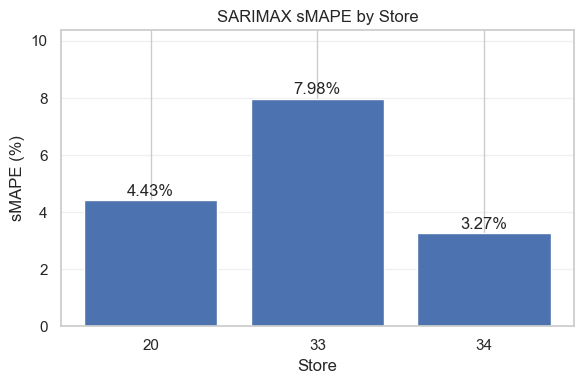

In [38]:
plt.figure(figsize=(6,4))

plt.bar(
    results_df["Store"].astype(str),
    results_df["sMAPE"],
    color="#4C72B0"
)

plt.title("SARIMAX sMAPE by Store")
plt.xlabel("Store")
plt.ylabel("sMAPE (%)")

plt.ylim(0, results_df["sMAPE"].max()*1.3)

for i, v in enumerate(results_df["sMAPE"]):
    plt.text(i, v + 0.15, f"{v:.2f}%", ha="center")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

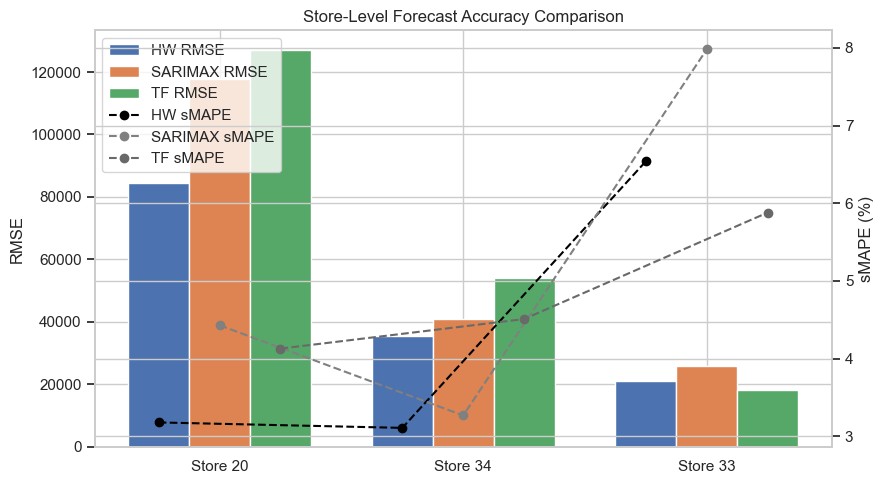

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")
palette = sns.color_palette("deep")

stores = ["Store 20","Store 34","Store 33"]

# RMSE
rmse_hw = [84613,35406,21112]
rmse_sarimax = [117765,41019,25869]
rmse_tf = [126968,54133,18243]

# sMAPE
smape_hw = [3.18,3.11,6.54]
smape_sarimax = [4.43,3.27,7.98]
smape_tf = [4.13,4.51,5.88]

x = np.arange(len(stores))
width = 0.25

fig, ax1 = plt.subplots(figsize=(9,5))

# RMSE bars
ax1.bar(x-width, rmse_hw, width, label="HW RMSE", color=palette[0])
ax1.bar(x, rmse_sarimax, width, label="SARIMAX RMSE", color=palette[1])
ax1.bar(x+width, rmse_tf, width, label="TF RMSE", color=palette[2])

ax1.set_ylabel("RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(stores)

# second axis
ax2 = ax1.twinx()

ax2.plot(x-width, smape_hw, marker="o", linestyle="--", color="black", label="HW sMAPE")
ax2.plot(x, smape_sarimax, marker="o", linestyle="--", color="gray", label="SARIMAX sMAPE")
ax2.plot(x+width, smape_tf, marker="o", linestyle="--", color="dimgray", label="TF sMAPE")

ax2.set_ylabel("sMAPE (%)")

# combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1+handles2, labels1+labels2, loc="upper left")

plt.title("Store-Level Forecast Accuracy Comparison")
plt.tight_layout()
plt.show()

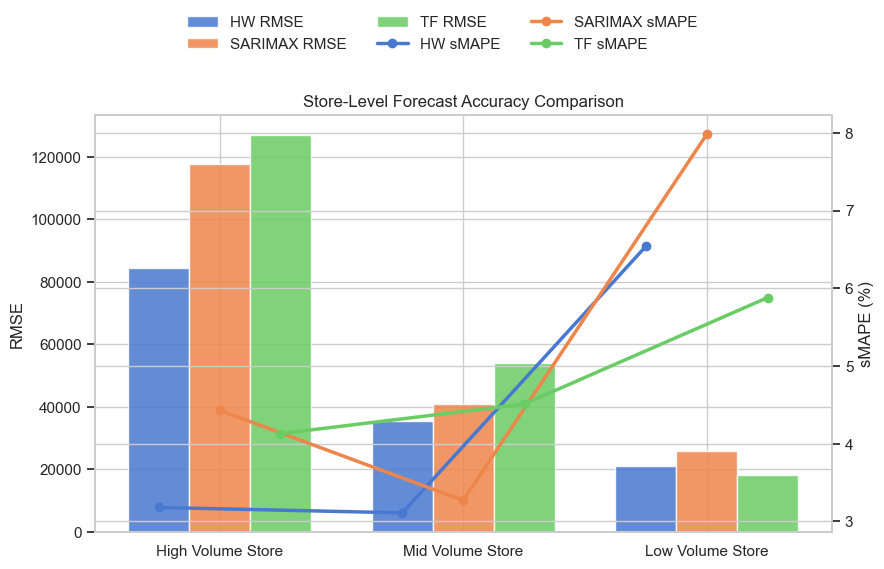

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")
palette = sns.color_palette("muted")

stores = ["High Volume Store","Mid Volume Store","Low Volume Store"]

rmse_hw = [84613,35406,21112]
rmse_sarimax = [117765,41019,25869]
rmse_tf = [126968,54133,18243]

smape_hw = [3.18,3.11,6.54]
smape_sarimax = [4.43,3.27,7.98]
smape_tf = [4.13,4.51,5.88]

x = np.arange(len(stores))
width = 0.25

fig, ax1 = plt.subplots(figsize=(9,5))

# RMSE bars
ax1.bar(x-width, rmse_hw, width, label="HW RMSE", color=palette[0], alpha=0.85)
ax1.bar(x, rmse_sarimax, width, label="SARIMAX RMSE", color=palette[1], alpha=0.85)
ax1.bar(x+width, rmse_tf, width, label="TF RMSE", color=palette[2], alpha=0.85)

ax1.set_ylabel("RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(stores)

# second axis
ax2 = ax1.twinx()

ax2.plot(x-width, smape_hw, marker="o", linewidth=2.5, color=palette[0], label="HW sMAPE")
ax2.plot(x, smape_sarimax, marker="o", linewidth=2.5, color=palette[1], label="SARIMAX sMAPE")
ax2.plot(x+width, smape_tf, marker="o", linewidth=2.5, color=palette[2], label="TF sMAPE")

ax2.set_ylabel("sMAPE (%)")

# combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5,1.15)
)

plt.title("Store-Level Forecast Accuracy Comparison")

plt.tight_layout()
plt.show()

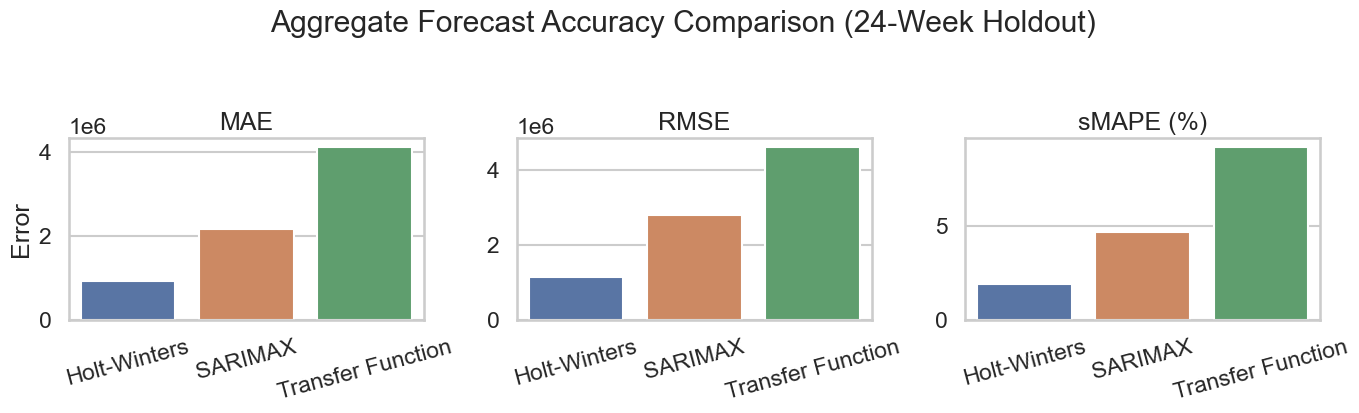

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", context="talk")

data = pd.DataFrame({
    "Model": ["Holt-Winters", "SARIMAX", "Transfer Function"],
    "MAE": [926482, 2164634, 4121956],
    "RMSE": [1146543, 2787751, 4609897],
    "sMAPE": [1.95, 4.7, 9.25]
})

palette = sns.color_palette("deep")

fig, axes = plt.subplots(1,3, figsize=(14,4))

sns.barplot(data=data, x="Model", y="MAE", ax=axes[0], palette=palette)
axes[0].set_title("MAE")
axes[0].set_ylabel("Error")
axes[0].set_xlabel("")

sns.barplot(data=data, x="Model", y="RMSE", ax=axes[1], palette=palette)
axes[1].set_title("RMSE")
axes[1].set_ylabel("")
axes[1].set_xlabel("")

sns.barplot(data=data, x="Model", y="sMAPE", ax=axes[2], palette=palette)
axes[2].set_title("sMAPE (%)")
axes[2].set_ylabel("")
axes[2].set_xlabel("")

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle("Aggregate Forecast Accuracy Comparison (24-Week Holdout)", y=1.05)

plt.tight_layout()
plt.show()

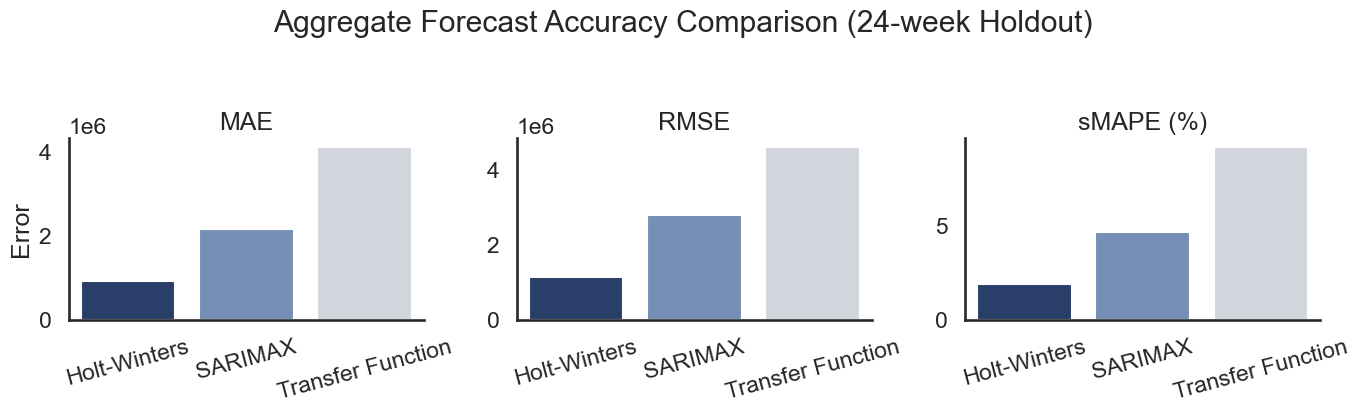

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="white", context="talk")

data = pd.DataFrame({
    "Model": ["Holt-Winters", "SARIMAX", "Transfer Function"],
    "MAE": [926482, 2164634, 4121956],
    "RMSE": [1146543, 2787751, 4609897],
    "sMAPE": [1.95, 4.7, 9.25]
})

colors = ["#1f3b73", "#6c8ebf", "#d0d5dd"]

fig, axes = plt.subplots(1,3, figsize=(14,4))

sns.barplot(data=data, x="Model", y="MAE", ax=axes[0], palette=colors)
axes[0].set_title("MAE")
axes[0].set_xlabel("")
axes[0].set_ylabel("Error")

sns.barplot(data=data, x="Model", y="RMSE", ax=axes[1], palette=colors)
axes[1].set_title("RMSE")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.barplot(data=data, x="Model", y="sMAPE", ax=axes[2], palette=colors)
axes[2].set_title("sMAPE (%)")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle("Aggregate Forecast Accuracy Comparison (24-week Holdout)", y=1.05)

plt.tight_layout()
plt.show()

Backtesting holiday season

Train size: 91
Test size : 9
Holiday Backtest RMSE: 2750541.060999205
Holiday Backtest MAE: 1781563.6671549354


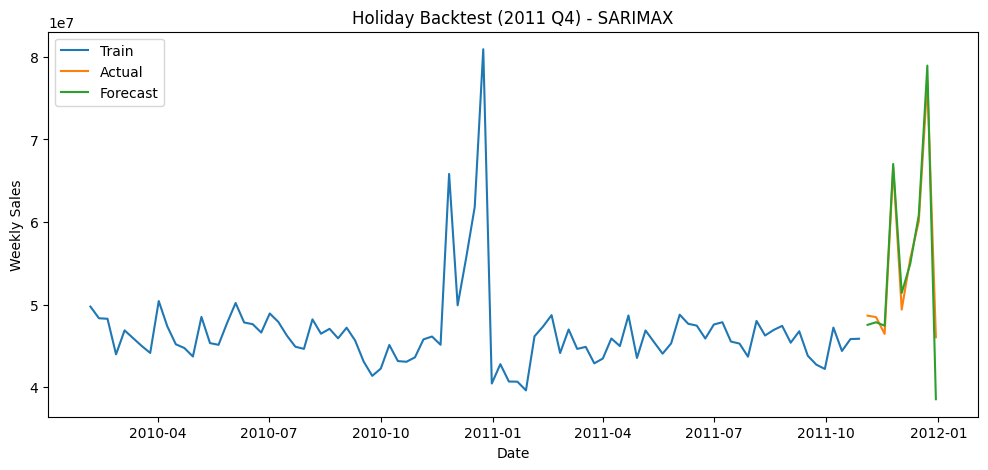

In [4]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

df = pd.read_csv("walmart_total_weekly.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# exogenous variables
exog_cols = [
    "holiday_share",
    "avg_temp",
    "avg_fuel_price",
    "avg_cpi",
    "avg_unemployment"
]

# Holiday backtest split
train_holiday = df[df["Date"] <= "2011-10-28"]
test_holiday  = df[(df["Date"] > "2011-10-28") & (df["Date"] <= "2011-12-30")]

print("Train size:", len(train_holiday))
print("Test size :", len(test_holiday))

model = SARIMAX(
    train_holiday["total_weekly_sales"],
    exog=train_holiday[exog_cols],
    order=(1,1,1),
    seasonal_order=(0,1,0,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)

forecast = res.get_forecast(
    steps=len(test_holiday),
    exog=test_holiday[exog_cols]
)

pred = forecast.predicted_mean

rmse = np.sqrt(mean_squared_error(test_holiday["total_weekly_sales"], pred))
mae = mean_absolute_error(test_holiday["total_weekly_sales"], pred)

print("Holiday Backtest RMSE:", rmse)
print("Holiday Backtest MAE:", mae)

plt.figure(figsize=(12,5))

plt.plot(train_holiday["Date"], train_holiday["total_weekly_sales"], label="Train")
plt.plot(test_holiday["Date"], test_holiday["total_weekly_sales"], label="Actual")
plt.plot(test_holiday["Date"], pred, label="Forecast")

plt.title("Holiday Backtest (2011 Q4) - SARIMAX")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()